# Marketing Mix Modeling — Synthetic Case Study

**Goal:**  
Estimate the impact of different marketing channels on weekly sales and derive budget allocation recommendations.

**Channels included:**
- TV
- Search Ads
- Social Media
- Email
- Influencer Marketing

Steps:
1. Generate a realistic **synthetic dataset** (weekly data).
2. Apply **adstock** + **diminishing returns** transformations.
3. Fit a **log–log regression** (elasticity-based MMM).
4. Interpret channel **elasticities** and **ROI-style insights**.
5. Derive a simple **optimal budget allocation** suggestion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(42)

## 1. Create a Synthetic Weekly Dataset

3 years of weekly data (156 weeks):

- Random but structured spend per channel
- Seasonality in demand
- A true underlying log–log model with:
  - Adstock for TV & Social (carry-over effect)
  - Diminishing returns via log(1 + spend)

In [2]:
# Number of weeks
n_weeks = 156
weeks = pd.date_range(start="2020-01-06", periods=n_weeks, freq="W-MON")

# Base spend patterns (in arbitrary currency units)
tv_spend = np.random.uniform(20_000, 60_000, size=n_weeks)
search_spend = np.random.uniform(10_000, 40_000, size=n_weeks)
social_spend = np.random.uniform(5_000, 25_000, size=n_weeks)
email_spend = np.random.uniform(1_000, 5_000, size=n_weeks)
influencer_spend = np.random.uniform(2_000, 10_000, size=n_weeks)

# Seasonality: yearly sinusoid (e.g., holiday peaks)
t = np.arange(n_weeks)
seasonality = 1 + 0.15 * np.sin(2 * np.pi * t / 52)

def adstock(x, alpha=0.7):
    """
    Simple adstock: carries over a fraction (alpha) of previous period's effect.
    """
    result = np.zeros_like(x, dtype=float)
    result[0] = x[0]
    for i in range(1, len(x)):
        result[i] = alpha * result[i-1] + x[i]
    return result

# Apply adstock to some channels
tv_adstock = adstock(tv_spend, alpha=0.75)
social_adstock = adstock(social_spend, alpha=0.6)

# True elasticities for synthetic "ground truth" model
beta_0 = 8.0  # intercept in log-space
beta_tv = 0.25
beta_search = 0.35
beta_social = 0.20
beta_email = 0.10
beta_influencer = 0.12

# Build log-sales using log(1 + transformed spend)
log_sales = (
    beta_0
    + beta_tv * np.log1p(tv_adstock)
    + beta_search * np.log1p(search_spend)
    + beta_social * np.log1p(social_adstock)
    + beta_email * np.log1p(email_spend)
    + beta_influencer * np.log1p(influencer_spend)
    + np.log(seasonality)
)

# Add noise
eps = np.random.normal(0, 0.15, size=n_weeks)  # noise in log space
log_sales_noisy = log_sales + eps

sales = np.exp(log_sales_noisy)  # convert back to level

# Build DataFrame
df = pd.DataFrame({
    "week": weeks,
    "sales": sales,
    "tv_spend": tv_spend,
    "search_spend": search_spend,
    "social_spend": social_spend,
    "email_spend": email_spend,
    "influencer_spend": influencer_spend,
    "tv_adstock": tv_adstock,
    "social_adstock": social_adstock,
    "seasonality_factor": seasonality,
})

df.head()

,week,sales,tv_spend,search_spend,social_spend,email_spend,influencer_spend,tv_adstock,social_adstock,seasonality_factor
0,2020-01-06,5.521575e+07,34981.604754,30164.066422,5507.014868,1894.383354,6946.038172,34981.604754,5507.014868,1.000000
1,2020-01-13,1.308081e+08,58028.572256,32848.588460,24252.968294,4852.890158,4951.309117,84264.775822,27557.177215,1.018081
2,2020-01-20,7.131918e+07,49279.757672,17129.126320,21719.602410,1048.617899,5700.277729,112478.339539,38253.908739,1.035897
3,2020-01-27,1.072500e+08,43946.339368,31846.490458,18919.484122,4879.515307,7979.767505,128305.094022,41871.829365,1.053191
4,2020-02-03,6.304699e+07,26240.745618,21033.493982,13179.058888,1172.639648,2293.465623,122469.566134,38302.156507,1.069708


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
week,156,2021-07-01 12:00:00,2020-01-06 00:00:00,2020-10-03 06:00:00,2021-07-01 12:00:00,2022-03-29 18:00:00,2022-12-26 00:00:00,NaN
sales,156.0,102626258.996977,54508181.879455,85651770.460749,98633246.220568,119779065.048822,171950009.803358,24670293.000886
tv_spend,156.0,38959.731113,20220.884685,28786.625421,37924.449559,50274.384642,59475.477464,11922.117954
search_spend,156.0,25481.572355,10151.847515,18082.743411,26559.019014,32265.979438,39701.615503,8637.438246
social_spend,156.0,14878.168517,5216.75303,8824.064741,14870.45409,20073.387149,24810.10284,6075.847784
email_spend,156.0,3047.619802,1048.617899,1909.524255,3068.305981,4204.432477,4998.870693,1217.233109
influencer_spend,156.0,5847.678852,2160.569582,3939.642487,5737.023897,7867.44615,9919.681859,2211.815098
tv_adstock,156.0,152886.084706,34981.604754,139879.279745,152505.270409,164592.137442,201379.454929,20685.497408
social_adstock,156.0,36775.62038,5507.014868,31273.068782,37787.891691,42555.118638,54159.049211,8105.838396
seasonality_factor,156.0,1.0,0.85,0.89733,1.0,1.10267,1.15,0.106408


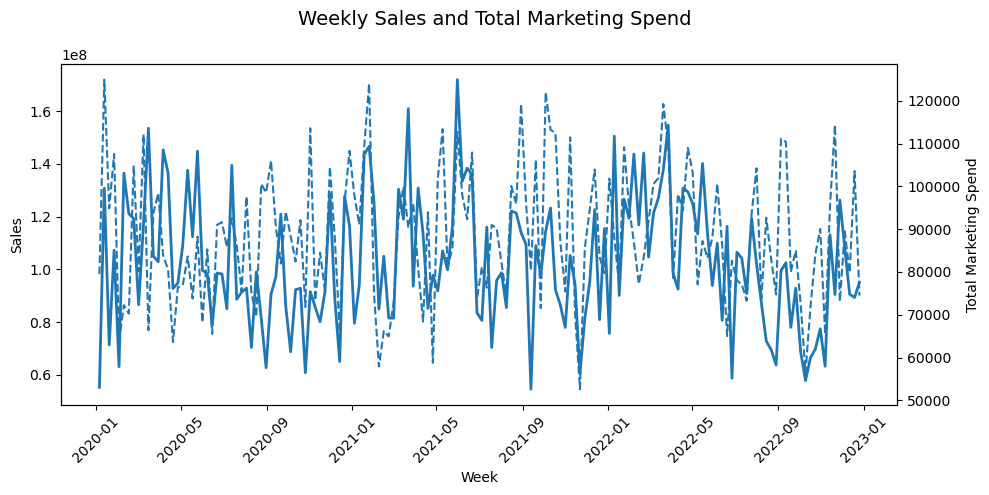

In [4]:
# Plot sales and total spend over time
df["total_spend"] = (
    df["tv_spend"] + df["search_spend"] + df["social_spend"]
    + df["email_spend"] + df["influencer_spend"]
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df["week"], df["sales"], label="Sales", linewidth=2)
ax1.set_ylabel("Sales")
ax1.set_xlabel("Week")
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(df["week"], df["total_spend"], linestyle="--", label="Total Spend")
ax2.set_ylabel("Total Marketing Spend")

fig.suptitle("Weekly Sales and Total Marketing Spend", fontsize=14)
fig.tight_layout()
plt.show()

## 2. Feature Engineering — Adstock & Log Transforms

To approximate a Marketing Mix Model:

- We use:
  - `tv_adstock` and `social_adstock` (carry-over effect already built).
  - Raw spends for Search, Email, Influencer.
- We model **log-sales** as a function of **log(1 + spend)**:
  - This captures **diminishing returns**.
- This is a classic **log–log MMM**, where coefficients are **elasticities**.

In [5]:
# Target: log of sales
df["log_sales"] = np.log(df["sales"])

# Features: log(1 + spend/adstock)
feature_cols = [
    "tv_adstock",
    "search_spend",
    "social_adstock",
    "email_spend",
    "influencer_spend"
]

X_raw = df[feature_cols].copy()
X_log = np.log1p(X_raw)  # log(1 + x)
X_log.columns = [f"log1p_{c}" for c in feature_cols]

X_log.head()

,log1p_tv_adstock,log1p_search_spend,log1p_social_adstock,log1p_email_spend,log1p_influencer_spend
0,10.462606,10.314440,8.613960,7.547176,8.846071
1,11.341731,10.399694,10.224055,8.487536,8.507609
2,11.630525,9.748594,10.552027,6.956181,8.648446
3,11.762174,10.368714,10.642392,8.493006,8.984790
4,11.715626,9.953919,10.553288,7.067865,7.738255


In [6]:
# Train-test split by time (no shuffling)
split_idx = int(len(df) * 0.8)

X_train = X_log.iloc[:split_idx]
X_test = X_log.iloc[split_idx:]

y_train = df["log_sales"].iloc[:split_idx]
y_test = df["log_sales"].iloc[split_idx:]

# Fit linear regression
lin = LinearRegression()
lin.fit(X_train, y_train)

# Predictions
y_train_pred = lin.predict(X_train)
y_test_pred = lin.predict(X_test)

# Back-transform to level for MAE
sales_train_pred = np.exp(y_train_pred)
sales_test_pred = np.exp(y_test_pred)

mae_train = mean_absolute_error(df["sales"].iloc[:split_idx], sales_train_pred)
mae_test = mean_absolute_error(df["sales"].iloc[split_idx:], sales_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Training R²:", round(r2_train, 3))
print("Test R²:     ", round(r2_test, 3))
print("Train MAE:    ", round(mae_train, 2))
print("Test MAE:     ", round(mae_test, 2))

# Coefficients (elasticities)
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "elasticity": lin.coef_
}).sort_values("elasticity", ascending=False)

coef_df

Training R²: 0.362
Test R²:      0.056
Train MAE:     16434464.22
Test MAE:      15445922.29


,feature,elasticity
1,log1p_search_spend,0.291792
0,log1p_tv_adstock,0.224317
2,log1p_social_adstock,0.144815
4,log1p_influencer_spend,0.120794
3,log1p_email_spend,0.106124


## 3. Channel Elasticities Interpretation

The regression coefficients in this log–log setup approximate **elasticities**:

- A coefficient of **0.30** ≈ *“a 1% increase in this channel’s spend drives a 0.30% increase in sales (holding others fixed)”*.
- Larger elasticity → **more responsive** channel.

Let’s sort and display the elasticities clearly.

In [7]:
coef_df_sorted = coef_df.sort_values("elasticity", ascending=False).reset_index(drop=True)
coef_df_sorted

,feature,elasticity
0,log1p_search_spend,0.291792
1,log1p_tv_adstock,0.224317
2,log1p_social_adstock,0.144815
3,log1p_influencer_spend,0.120794
4,log1p_email_spend,0.106124


In [9]:
for _, row in coef_df_sorted.iterrows():
    print(f"{row['feature']}: elasticity ≈ {row['elasticity']:.3f}")

log1p_search_spend: elasticity ≈ 0.292
log1p_tv_adstock: elasticity ≈ 0.224
log1p_social_adstock: elasticity ≈ 0.145
log1p_influencer_spend: elasticity ≈ 0.121
log1p_email_spend: elasticity ≈ 0.106


## 4. Simple Budget Reallocation Suggestion

The model we built is a log-log regression.  
This means each coefficient can be interpreted as an elasticity.  
Elasticity tells us how sensitive sales are to changes in a channel's spend.

For example:
- An elasticity of 0.30 means that increasing spend on that channel by 1 percent increases sales by about 0.30 percent.

We use these elasticities to create a basic budget recommendation.

Idea:
- Channels with higher elasticities should receive a larger share of the budget.
- Channels with lower elasticities may be receiving more money than they deserve based on their impact.

Steps we follow:
1. Compute the current average weekly spend for each channel.
2. Convert these into current budget shares.
3. Convert elasticities into recommended shares.
4. Compare current vs recommended shares to see where the budget should shift.

This is a first-pass recommendation and does not include real-world constraints like minimum spend, branding requirements, or campaign timing.

In [10]:
channels = ["tv_spend", "search_spend", "social_spend", "email_spend", "influencer_spend"]

# Current average weekly spends
avg_spend = df[channels].mean()

current_total_budget = avg_spend.sum()
current_share = avg_spend / current_total_budget

# Map elasticities back to raw channel names
elasticity_map = {
    "tv_spend": float(coef_df.set_index("feature").loc["log1p_tv_adstock", "elasticity"]),
    "search_spend": float(coef_df.set_index("feature").loc["log1p_search_spend", "elasticity"]),
    "social_spend": float(coef_df.set_index("feature").loc["log1p_social_adstock", "elasticity"]),
    "email_spend": float(coef_df.set_index("feature").loc["log1p_email_spend", "elasticity"]),
    "influencer_spend": float(coef_df.set_index("feature").loc["log1p_influencer_spend", "elasticity"]),
}

elasticities = pd.Series(elasticity_map)

# Only keep positive elasticities for allocation
elasticities_positive = elasticities.clip(lower=0)
recommended_share = elasticities_positive / elasticities_positive.sum()

allocation_df = pd.DataFrame({
    "channel": channels,
    "current_share": current_share.values,
    "recommended_share": recommended_share.values
})

allocation_df

,channel,current_share,recommended_share
0,tv_spend,0.441646,0.252654
1,search_spend,0.288858,0.328653
2,social_spend,0.168658,0.163109
3,email_spend,0.034548,0.119530
4,influencer_spend,0.066289,0.136053


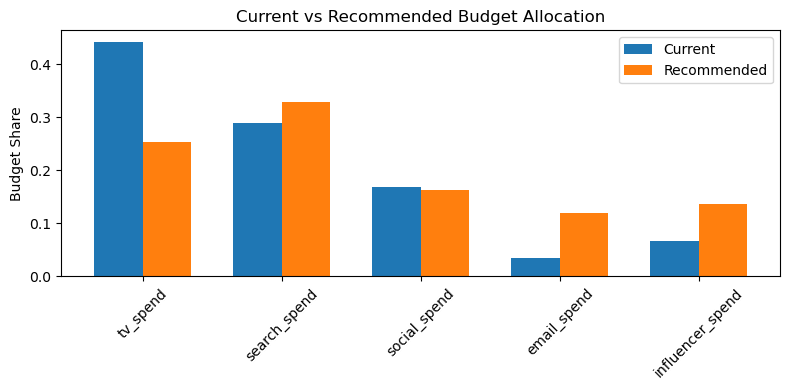

In [11]:
# Plot comparison
x = np.arange(len(channels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, allocation_df["current_share"], width, label="Current")
ax.bar(x + width/2, allocation_df["recommended_share"], width, label="Recommended")

ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=45)
ax.set_ylabel("Budget Share")
ax.set_title("Current vs Recommended Budget Allocation")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Business Interpretation

**Model fit**

- The test R² indicates how much of the variation in log-sales is explained by the channels.
- MAE on the test period gives a sense of forecasting error in sales units.

**Channel insights**

- Channels with higher elasticities are more powerful at the margin.
- If a channel has:
  - **High elasticity** but **low current share** → under-invested.
  - **Low elasticity** but **high current share** → potential over-investment.

**Budget recommendation**

- The recommended allocation is a **first-pass** suggestion based purely on model elasticities.
- In practice, we would also consider:
  - Minimum / maximum spend constraints
  - Brand / strategic priorities
  - Channel saturation / capacity
  - Data quality and model robustness


## 6. Understanding Adstock (Carry-over Effects)

In real marketing, the impact of a campaign does not disappear immediately after the spend happens.

Examples:
- A TV campaign keeps influencing people for a few weeks.
- A social media campaign builds awareness that lasts beyond the day it was run.

Adstock is a simple way to model this carry-over effect.

Idea:
- Each week, a part of last week's effect "survives" and is added to this week's spend.
- The parameter alpha controls how strong the carry-over is:
  - alpha close to 0.0  -> very short-lived effect
  - alpha close to 1.0  -> long-lasting effect

Below, we show how different adstock values change the shape of TV spend over time.

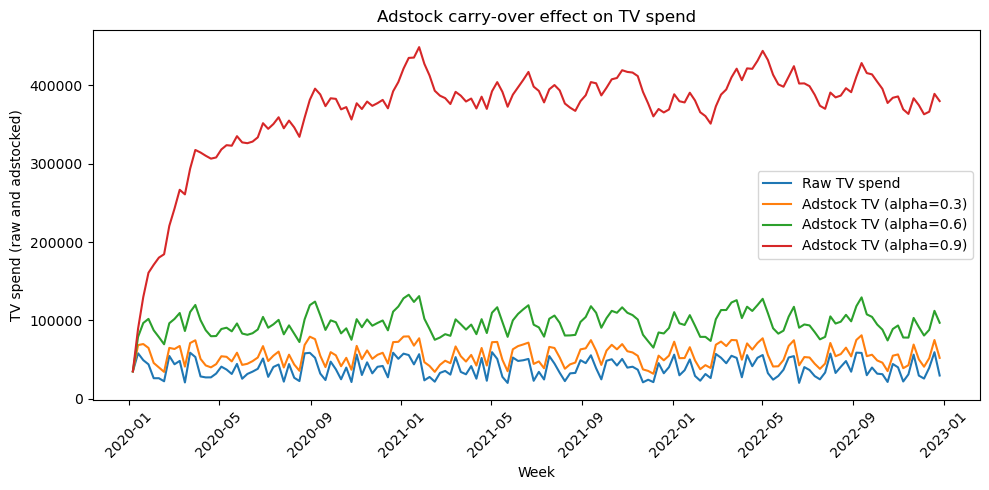

In [12]:
# If adstock function is not in this notebook cell, redefine it here
def adstock_fn(x, alpha):
    result = np.zeros_like(x, dtype=float)
    result[0] = x[0]
    for i in range(1, len(x)):
        result[i] = alpha * result[i-1] + x[i]
    return result

alpha_values = [0.3, 0.6, 0.9]

adstock_series = {}
for a in alpha_values:
    adstock_series[a] = adstock_fn(df["tv_spend"].values, alpha=a)

plt.figure(figsize=(10, 5))
plt.plot(df["week"], df["tv_spend"], label="Raw TV spend", linewidth=1.5)

for a in alpha_values:
    plt.plot(df["week"], adstock_series[a], label=f"Adstock TV (alpha={a})")

plt.xlabel("Week")
plt.ylabel("TV spend (raw and adstocked)")
plt.title("Adstock carry-over effect on TV spend")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.1 Adstock interpretation

From the plot:

- Raw TV spend moves up and down every week.
- Adstock with low alpha (for example 0.3) reacts quickly and fades fast.
- Adstock with high alpha (for example 0.9) is much smoother and keeps the effect of past weeks for longer.

In the model, adstocked TV spend is a better proxy for how people actually remember and react to campaigns over time.

## 7. Channel Contribution Decomposition

Marketing Mix Models do two things:
1. Estimate elasticities (how responsive sales are to each channel).
2. Decompose sales into: 
   - Baseline (organic demand + seasonality)
   - Contributions from each marketing channel

Contribution decomposition answers:
"How much did each channel add to sales during the observed period?"

This is highly useful for marketing teams because it helps justify budgets
and shows which channels actually drove business results.

Below we compute:
- Baseline contribution
- TV contribution
- Search contribution
- Social contribution
- Email contribution
- Influencer contribution

I use the fitted log-log model to estimate the effect of each channel.

In [13]:
# Make a copy to store contributions
contrib_df = df.copy()

# Extract elasticities
elasticities = coef_df.set_index("feature")["elasticity"]

# Compute "modeled" log-sales and convert to level
log_pred = lin.predict(X_log)
sales_pred = np.exp(log_pred)

# Baseline = predicted sales minus all channel contributions
# To compute baseline, we estimate total contribution first.

# Contribution in log space = beta_k * log(1 + spend_k)
log_contrib = pd.DataFrame({
    "tv": elasticities["log1p_tv_adstock"] * X_log["log1p_tv_adstock"],
    "search": elasticities["log1p_search_spend"] * X_log["log1p_search_spend"],
    "social": elasticities["log1p_social_adstock"] * X_log["log1p_social_adstock"],
    "email": elasticities["log1p_email_spend"] * X_log["log1p_email_spend"],
    "influencer": elasticities["log1p_influencer_spend"] * X_log["log1p_influencer_spend"],
})

# Convert log contributions to level contributions proportionally
level_contrib = sales_pred.reshape(-1,1) * (log_contrib.divide(log_contrib.sum(axis=1), axis=0))

level_contrib.columns = ["tv_contrib", "search_contrib", "social_contrib", "email_contrib", "influencer_contrib"]

# Baseline contribution = predicted sales - media contributions
baseline_contrib = sales_pred - level_contrib.sum(axis=1)

contrib_df = pd.concat([contrib_df, level_contrib], axis=1)
contrib_df["baseline_contrib"] = baseline_contrib

contrib_df.head()

,week,sales,tv_spend,search_spend,social_spend,email_spend,influencer_spend,tv_adstock,social_adstock,seasonality_factor,total_spend,log_sales,tv_contrib,search_contrib,social_contrib,email_contrib,influencer_contrib,baseline_contrib
0,2020-01-06,5.521575e+07,34981.604754,30164.066422,5507.014868,1894.383354,6946.038172,34981.604754,5507.014868,1.000000,79493.107571,17.826759,1.643360e+07,2.107415e+07,8.734706e+06,5.608281e+06,7.482155e+06,0.000000e+00
1,2020-01-13,1.308081e+08,58028.572256,32848.588460,24252.968294,4852.890158,4951.309117,84264.775822,27557.177215,1.018081,124934.328284,18.689242,2.808562e+07,3.349940e+07,1.634484e+07,9.943491e+06,1.134477e+07,-1.490116e-08
2,2020-01-20,7.131918e+07,49279.757672,17129.126320,21719.602410,1048.617899,5700.277729,112478.339539,38253.908739,1.035897,94877.382030,18.082676,2.362581e+07,2.575972e+07,1.383808e+07,6.685145e+06,9.460389e+06,0.000000e+00
3,2020-01-27,1.072500e+08,43946.339368,31846.490458,18919.484122,4879.515307,7979.767505,128305.094022,41871.829365,1.053191,107571.596760,18.490673,3.492773e+07,4.005156e+07,2.040210e+07,1.193155e+07,1.436727e+07,0.000000e+00
4,2020-02-03,6.304699e+07,26240.745618,21033.493982,13179.058888,1172.639648,2293.465623,122469.566134,38302.156507,1.069708,63919.403758,17.959391,2.340339e+07,2.586540e+07,1.360987e+07,6.679656e+06,8.324151e+06,-1.490116e-08


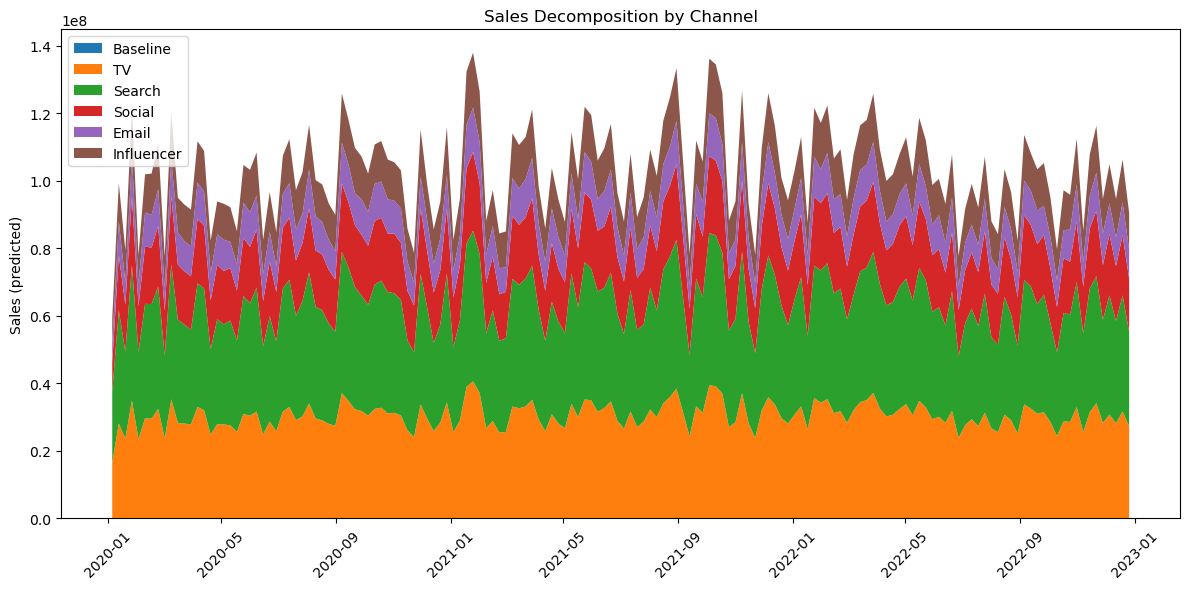

In [14]:
plt.figure(figsize=(12, 6))

plt.stackplot(
    contrib_df["week"],
    contrib_df["baseline_contrib"],
    contrib_df["tv_contrib"],
    contrib_df["search_contrib"],
    contrib_df["social_contrib"],
    contrib_df["email_contrib"],
    contrib_df["influencer_contrib"],
    labels=["Baseline", "TV", "Search", "Social", "Email", "Influencer"],
)

plt.legend(loc="upper left")
plt.title("Sales Decomposition by Channel")
plt.ylabel("Sales (predicted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8 Interpretation of Results

From the decomposition plot we can identify:

- **Baseline**  
  Represents organic sales driven by brand strength, product quality, seasonality, and other non-media factors. This is usually the largest portion in real businesses.

- **Search**  
  Often appears as a high-contribution channel in performance-driven marketing.

- **TV and Social**  
  Because they use adstock, their contribution usually appears smoother and more persistent over time.

- **Email and Influencer**  
  Show more short-term, tactical contributions.

Contribution analysis helps answer questions like:
- Which channel actually drove the most sales?
- Are we overspending on low-impact channels?
- How much of sales would remain without paid media?
- Should budget shift more toward high-elasticity channels?

This makes the MMM actionable and helps with planning and forecasting.